# 01 - CV Transformer Training and 
CV Extraction


In [15]:
import sys
from pathlib import Path

SRC_DIR = (Path.cwd().resolve() / '..' / 'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Hard-reload local package modules so notebook always sees latest edits.
for name in list(sys.modules.keys()):
    if name == 'course_project' or name.startswith('course_project.'):
        del sys.modules[name]

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from graph_utils import calc_p_ratio_box

from course_project.config import ExperimentConfig
from course_project.runner import run_experiment
from course_project.data import load_dataset
from course_project.graph import build_graph
from course_project.hessian import collect_cv_lambda5_points
from course_project.models import create_model, resolve_model_inputs



In [ ]:
import random
import shutil

seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

fixed_params = {
    'K1': 300,
    'hidden_size': 64,
    'learning_rate': 3e-4,
}

common_cfg = dict(
    train_dataset='../data/data_aux_opt_lowT_448sims_noang_bidirect_train5.pt',
    val_dataset='../data/data_aux_opt_lowT_448sims_noang_bidirect_val100.pt',
    output_root='../results',
    device='cuda',
    pos_dim=2,
    history=1,
    limit=20,
    n_layers=2,
    learning_rate_decay=0.997,
    epochs=100,
    val_every=10,
    rollout_steps=10,
    cv_pratio_target='box',
    rollout_every=10,
    cv_eval_every=10,
    train_rollout_steps=1,
    train_rollout_loss_decay=0.9,
    freeze_normalizers_after_epoch=200,
)

use_existing_best_cv = False
selection_json = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_selection.json'
best_ckpt_out = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_checkpoint.pt'

if use_existing_best_cv and selection_json.exists() and best_ckpt_out.exists():
    selection = json.loads(selection_json.read_text())
    best_run_name = selection['run_name']
    best_cfg = json.loads((Path(common_cfg['output_root']) / best_run_name / 'config.json').read_text())
    cfg_cv_transformer = ExperimentConfig(**best_cfg)

    print('Loaded existing best CV selection')
    print('Best run:', best_run_name)
    print('Best cv_fit_r2:', float(selection['best_cv_fit_r2']))
    print('Best checkpoint for downstream use:', best_ckpt_out)

    runs = pd.read_csv(Path(common_cfg['output_root']) / 'cv_transformer_fixed_multi_run_summary.csv') if (Path(common_cfg['output_root']) / 'cv_transformer_fixed_multi_run_summary.csv').exists() else pd.DataFrame()
else:
    repeats = 5
    seed_base = 1235
    rows = []

    for i in range(repeats):
        run_seed = seed_base + i

        cfg = ExperimentConfig(
            run_name=f'cv_transformer_fixed_r{i+1:02d}',
            model_type='cv_transformer',
            seed=run_seed,
            hidden_size=int(fixed_params['hidden_size']),
            learning_rate=float(fixed_params['learning_rate']),
            model_extras={
                'num_mlp': 3,
                'K1': int(fixed_params['K1']),
                'CV': 2,
                'transformer_layers': 1,
                'transformer_heads': 1,
                'transformer_dropout': 0.001,
                'edge_aggr': 'mean',
                'use_local_skip': True,
            },
            **common_cfg,
        )

        metrics = run_experiment(cfg)

        run_dir = Path(cfg.output_root) / cfg.run_name
        stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)
        epochs = np.asarray(stats['epoch'], dtype=int)
        cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)

        best_idx = int(np.nanargmax(cv_fit_r2))
        best_epoch = int(epochs[best_idx])
        best_score = float(cv_fit_r2[best_idx])
        best_ckpt = run_dir / 'rollout_checkpoints' / f'epoch_{best_epoch:04d}.pt'

        rows.append({
            'repeat': i + 1,
            'seed': run_seed,
            'run_name': cfg.run_name,
            'best_cv_fit_r2': best_score,
            'best_cv_epoch': best_epoch,
            'checkpoint_path': str(best_ckpt),
            'selected_checkpoint_score': float(metrics['selected_checkpoint_score']),
        })

    runs = pd.DataFrame(rows).sort_values('best_cv_fit_r2', ascending=False).reset_index(drop=True)
    best = runs.iloc[0]

    best_cv_ckpt = Path(best['checkpoint_path'])
    shutil.copy2(best_cv_ckpt, best_ckpt_out)

    summary_csv = Path(common_cfg['output_root']) / 'cv_transformer_fixed_multi_run_summary.csv'
    runs.to_csv(summary_csv, index=False)

    selection = {
        'run_name': str(best['run_name']),
        'best_cv_fit_r2': float(best['best_cv_fit_r2']),
        'best_cv_epoch': int(best['best_cv_epoch']),
        'checkpoint_path': str(best_cv_ckpt),
        'saved_checkpoint_path': str(best_ckpt_out),
        'fixed_params': fixed_params,
        'repeats': repeats,
    }
    selection_json.write_text(json.dumps(selection, indent=2))

    best_cfg = json.loads((Path(common_cfg['output_root']) / str(best['run_name']) / 'config.json').read_text())
    cfg_cv_transformer = ExperimentConfig(**best_cfg)

    print('Saved best checkpoint for notebook 02:', best_ckpt_out)
    print('Best CV fit R2:', selection['best_cv_fit_r2'], 'run:', selection['run_name'], 'epoch:', selection['best_cv_epoch'])
    print('Saved summary CSV:', summary_csv)
    print('Saved selection JSON:', selection_json)

runs



[run] cv_transformer_fixed_r01 model=cv_transformer device=cuda output=../results/cv_transformer_fixed_r01
[run] training...
[train] autoregressive loss steps=1 decay=0.9
[ep  10/100] tr=0.911 va=0.94 lr=0.000291 roll=r2=0.229 p=0.978 mse=3.6e-07 (100/100) cv=|p|=0.414 r2=0.171 (n=100) t=57.3s
[ep  20/100] tr=0.913 va=0.94 lr=0.000283 roll=r2=0.231 p=0.978 mse=3.59e-07 (100/100) cv=|p|=0.13 r2=0.0168 (n=100) t=19.2s
[ep  30/100] tr=0.914 va=0.94 lr=0.000274 roll=r2=0.23 p=0.977 mse=3.6e-07 (100/100) cv=|p|=0.31 r2=0.0962 (n=100) t=19.2s
[ep  40/100] tr=0.914 va=0.94 lr=0.000266 roll=r2=0.229 p=0.977 mse=3.59e-07 (100/100) cv=|p|=0.79 r2=0.624 (n=100) t=19.2s
[ep  50/100] tr=0.914 va=0.941 lr=0.000258 roll=r2=0.226 p=0.978 mse=3.6e-07 (100/100) cv=|p|=0.351 r2=0.123 (n=100) t=19.2s
[ep  60/100] tr=0.914 va=0.941 lr=0.000251 roll=r2=0.223 p=0.978 mse=3.61e-07 (100/100) cv=|p|=0.315 r2=0.0989 (n=100) t=19.1s


KeyboardInterrupt: 

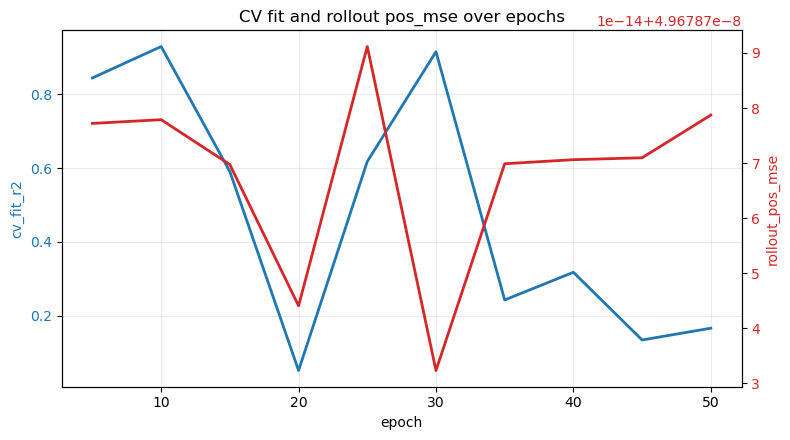

best cv_fit_r2= 0.9290038899079617 at epoch 10


In [ ]:
# Simple CV-fit metric over epochs + rollout pos_mse.
run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)

epochs = np.asarray(stats['epoch'], dtype=int)
cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)
rollout_pos_mse = np.asarray(stats['rollout_pos_mse'], dtype=float)

mask_cv = np.isfinite(cv_fit_r2)
mask_mse = np.isfinite(rollout_pos_mse)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(epochs[mask_cv], cv_fit_r2[mask_cv], '-', linewidth=2.0, label='cv_fit_r2', color='tab:blue')
ax1.set_xlabel('epoch')
ax1.set_ylabel('cv_fit_r2', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(epochs[mask_mse], rollout_pos_mse[mask_mse], '-', linewidth=2.0, label='rollout_pos_mse', color='tab:red')
ax2.set_ylabel('rollout_pos_mse', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title('CV fit and rollout pos_mse over epochs')
plt.tight_layout()
plt.show()

best_i = int(np.nanargmax(cv_fit_r2))
print('best cv_fit_r2=', float(cv_fit_r2[best_i]), 'at epoch', int(epochs[best_i]))



In [ ]:
# Load model from the saved best CV-fit checkpoint.
output_root = Path(cfg_cv_transformer.output_root)
selection = json.loads((output_root / 'cv_transformer_best_cv_selection.json').read_text())

run_dir = output_root / selection['run_name']
cfg_dict = json.loads((run_dir / 'config.json').read_text())
cfg_loaded = ExperimentConfig(**cfg_dict)

device = cfg_loaded.device
if device == 'cuda' and not torch.cuda.is_available():
    device = 'cpu'

val_data = load_dataset(cfg_loaded.val_dataset)
init_frames = [val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)]
init_graph = build_graph(input_graphs=init_frames).to(device)

model = create_model(
    model_type=cfg_loaded.model_type,
    init_graph=init_graph,
    pos_dim=cfg_loaded.pos_dim,
    hidden_size=cfg_loaded.hidden_size,
    n_layers=cfg_loaded.n_layers,
    extras=cfg_loaded.model_extras,
).to(device)

best_ckpt = Path(selection['saved_checkpoint_path'])
model.load_checkpoint(str(best_ckpt))

model.eval()
if hasattr(model, 'freeze_normalizers'):
    model.freeze_normalizers = True
for p in model.parameters():
    p.requires_grad = False
model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

print('Loaded model:', cfg_loaded.model_type, 'device=', device)
print('Run dir:', run_dir)
print('Loaded best CV checkpoint:', best_ckpt)
print('best cv_fit_r2:', float(selection['best_cv_fit_r2']), 'epoch:', int(selection['best_cv_epoch']))
print('effective num CVs (CV):', cfg_loaded.model_extras['CV'])



Loaded model: cv_transformer device= cuda
Run dir: ../results/cv_transformer_fixed_r04
Loaded best CV checkpoint: ../results/cv_transformer_best_cv_checkpoint.pt
best cv_fit_r2: 0.9290038899079617 epoch: 10
effective num CVs (CV): 2


In [ ]:
# Extract trajectory-level CV summaries and final p-ratio.
rows = []

with torch.no_grad():
    for sim_idx, sim in enumerate(val_data):
        n_local = min(cfg_loaded.rollout_steps, len(sim) - 1)

        final_pr = float(calc_p_ratio_box(sim, -1))

        cv_values = []
        for t in range(cfg_loaded.history, n_local):
            frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
            if t > 0:
                prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                frames[-1].vel_state = cur_pos - prev_pos

            input_graph = build_graph(frames).to(device)
            cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
            cv = np.asarray(cv, dtype=float).reshape(-1)
            cv_values.append(cv)

        cv_mean = np.mean(np.stack(cv_values, axis=0), axis=0)
        row = {
            'sim_idx': sim_idx,
            'num_frames_used': len(cv_values),
            'final_p_ratio': final_pr,
        }
        for i, value in enumerate(cv_mean, start=1):
            row[f'cv_{i}'] = float(value)
        rows.append(row)

df_cv = pd.DataFrame(rows).sort_values('sim_idx').reset_index(drop=True)
df_cv.head(), df_cv.shape



(   sim_idx  num_frames_used  final_p_ratio      cv_1      cv_2
 0        0                3      -0.476951  1.640263  1.640263
 1        1                3      -0.089937  1.650964  1.650964
 2        2                3       0.340988  1.661735  1.661735
 3        3                3       0.107329  1.651035  1.651035
 4        4                3      -0.029619  1.645437  1.645437,
 (100, 5))

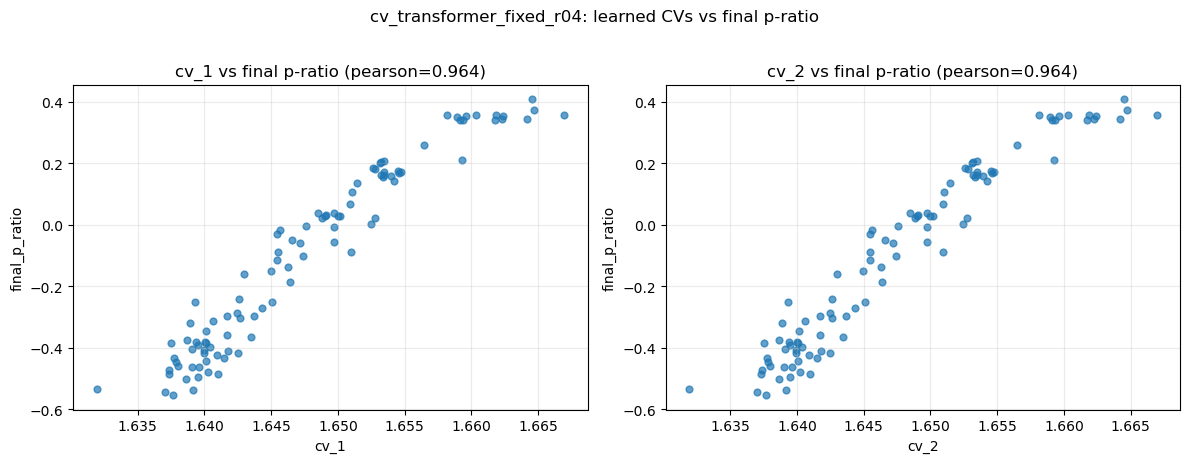

Saved: ../results/cv_transformer_fixed_r04/cv_transformer_cvs_vs_final_pratio.csv
Saved: ../results/cv_transformer_fixed_r04/cv_transformer_cvs_vs_final_pratio.png
final_p_ratio    1.000000
cv_1             0.963848
cv_2             0.963848
Name: final_p_ratio, dtype: float64


In [ ]:
# Plot each learned CV against final p-ratio and save outputs to the run folder (dots only).
cv_cols = [c for c in df_cv.columns if c.startswith('cv_')]

n = len(cv_cols)
ncols = 2 if n > 1 else 1
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cv_cols):
    x = df_cv[col].to_numpy(dtype=float)
    y = df_cv['final_p_ratio'].to_numpy(dtype=float)

    ax.scatter(x, y, s=24, alpha=0.7)

    r = float(np.corrcoef(x, y)[0, 1])
    ax.set_title(f'{col} vs final p-ratio (pearson={r:.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('final_p_ratio')
    ax.grid(alpha=0.25)

for ax in axes_flat[len(cv_cols):]:
    ax.axis('off')

fig.suptitle(f"{cfg_loaded.run_name}: learned CVs vs final p-ratio", y=1.02)
fig.tight_layout()

csv_path = run_dir / 'cv_transformer_cvs_vs_final_pratio.csv'
png_path = run_dir / 'cv_transformer_cvs_vs_final_pratio.png'
df_cv.to_csv(csv_path, index=False)
fig.savefig(png_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved:', csv_path)
print('Saved:', png_path)
print(df_cv[cv_cols + ['final_p_ratio']].corr()['final_p_ratio'].sort_values(ascending=False))



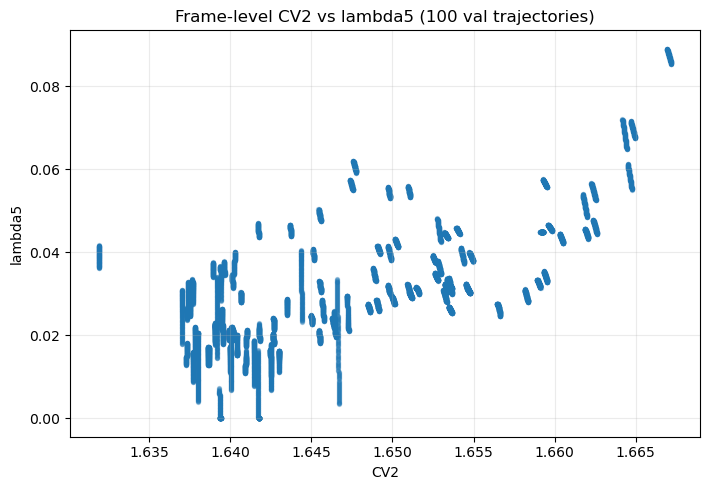

points: 15013
pearson(CV2, lambda5)= 0.6830098634576015


In [ ]:
# Single scatter plot: frame-level CV (CV2) vs lambda5 from Hessian, over 100 validation trajectories.
pts = collect_cv_lambda5_points(
    model,
    val_data,
    history=cfg_loaded.history,
    pos_dim=cfg_loaded.pos_dim,
    device=device,
    max_sims=100,
    cv_index=1,
)

x = pts['cv']
y = pts['lambda5']

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.scatter(x, y, s=8, alpha=0.35)
ax.set_xlabel('CV2')
ax.set_ylabel('lambda5')
ax.set_title('Frame-level CV2 vs lambda5 (100 val trajectories)')
ax.grid(alpha=0.25)
fig.tight_layout()

plt.show()

pearson = float(np.corrcoef(x, y)[0, 1])
print('points:', len(x))
print('pearson(CV2, lambda5)=', pearson)

